#Introduction

**Group 9**

Ali Abughazaleh 

Rawnak Tahnia 

Marvellous Oluwatola 

**The source of the dataset**

The data was found in Kaggle, and was presented by Willian Water under the name Human Resources Analytics: A Descriptive Analysis.

https://www.kaggle.com/code/colara/human-resources-analytics-a-descriptive-analysis/input

**About the Dataset**


The goal of this dataset collected from Kaggle, is to comprehend why the company's best and most experienced employees are departing. Retaining hardworking employees is a long-term strategy that can affect a company's growth. We can gain useful insights into a problem that the Human Resource department deal with on a regular basis by exploring this dataset. 


**Exploring the Variables**



*   satisfaction_level: Satisfaction level of the employee
*   last_evaluation: Last evaluation of the employee 
*   number_project: Number of projects the employee has worked on  
*   average_montly_hours: Average hours worked in a month
*  time_spend_company: Time the employee spent at the company
*   Work_accident: Whether an employee have had a work accident or not 
*  left: Whether an employee has left the company 
*   promotion_last_5years: Whether the employee have had a promotion in the last five years
*   sales: Department the employee belongs to
*   salary: Salary of the employee















**The Business Problem**




In the fast-paced and rapidly-evolving landscape of contemporary business, the ability to maintain a highly productive and engaged workforce is widely recognized as a critical factor in achieving sustained success. With this in mind, our company has initiated a test on this comprehensive dataset in order to construct a model that will provide valuable insights into the factors that contribute to employee turnover. By leveraging the power of data analysis and modeling techniques, we aim to gain a deeper understanding of the various drivers of employee turnover and attrition, ultimately informing our efforts to build a highly effective and resilient workforce and increase retention.









**The expected implications on solving the problem**




Employee turnover represents a pervasive and well-documented challenge faced by businesses across the globe. Failure to prioritize employee satisfaction and to implement effective retention strategies can have far-reaching consequences for organizational performance. Specifically, inadequate policies can lead to a decrease in overall productivity, impact the quality of customer service, result in lost profits, and ultimately erode employee engagement and motivation. 
In such an environment, employees may become disengaged, lacking the support and resources necessary to engage in initiatives and creative problem-solving.The result may be a situation in which employees view their work solely as a means of obtaining a salary, with no sense of ownership or investment in the organization. The cost of employee turnover can be significant, not only in terms of the direct costs associated with recruiting and training new employees, but also in the potential impact on the morale and workloads of the remaining employees. Furthermore, employees are human beings with the need for appreciation and motivation to foster critical and creative thinking. Failure to provide this support can result in a negative and demotivating work environment. Conversely, a supportive and nurturing work environment can promote employee satisfaction, engagement, and ultimately, retention.

#Importing the libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set_style("whitegrid",{'axes.grid' : True})
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score, roc_curve
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import MultinomialNB 

# Loading the dataset and Performing Exploratory Analysis

In [2]:
from google.colab import files
uploaded = files.upload()

import io
hr_data = pd.read_csv(io.BytesIO(uploaded['HR-Analytics.csv']))

Saving HR-Analytics.csv to HR-Analytics.csv


In [3]:
hr_data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


**Converting 'salary' into integer**

In [4]:
hr_data['salary'] = hr_data['salary'].map({'low':1, 'medium':2, 'high':3})

In [5]:
hr_data.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,1.594706
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,0.637183
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,1.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,1.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,2.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,2.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,3.000000


**Target Variable distribution**

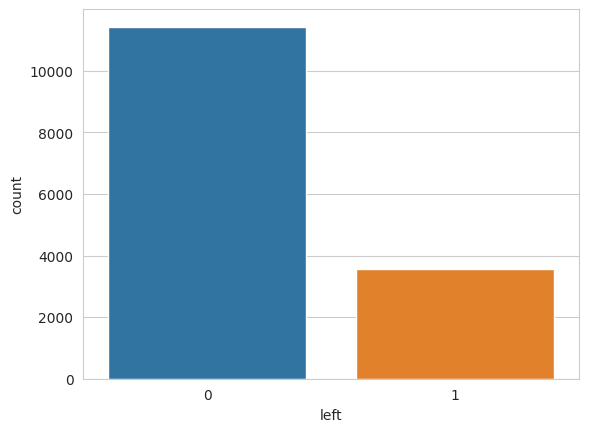

In [6]:
sns.countplot(x="left", data = hr_data)
plt.show()

In [7]:
print('Proportion of Employees that leave: ', hr_data.left.mean())

Proportion of Employees that leave:  0.2380825388359224


**Checking for missing/null values**

<Axes: >

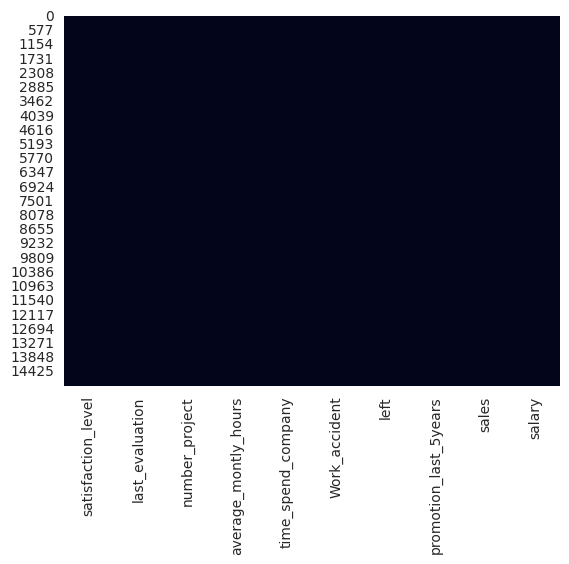

In [8]:
sns.heatmap(hr_data.isnull(), cbar=False)

**Dropping the 'sales' variable**

In [9]:
hr_data_clean = hr_data.drop(['sales'],axis=1)

In [10]:
print(hr_data_clean.isnull().sum())

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
salary                   0
dtype: int64


As we can see, there are no missing values in the dataset.

**Examining the data types**

In [11]:
print(hr_data_clean.dtypes)

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
salary                     int64
dtype: object


**Examining the distribution**

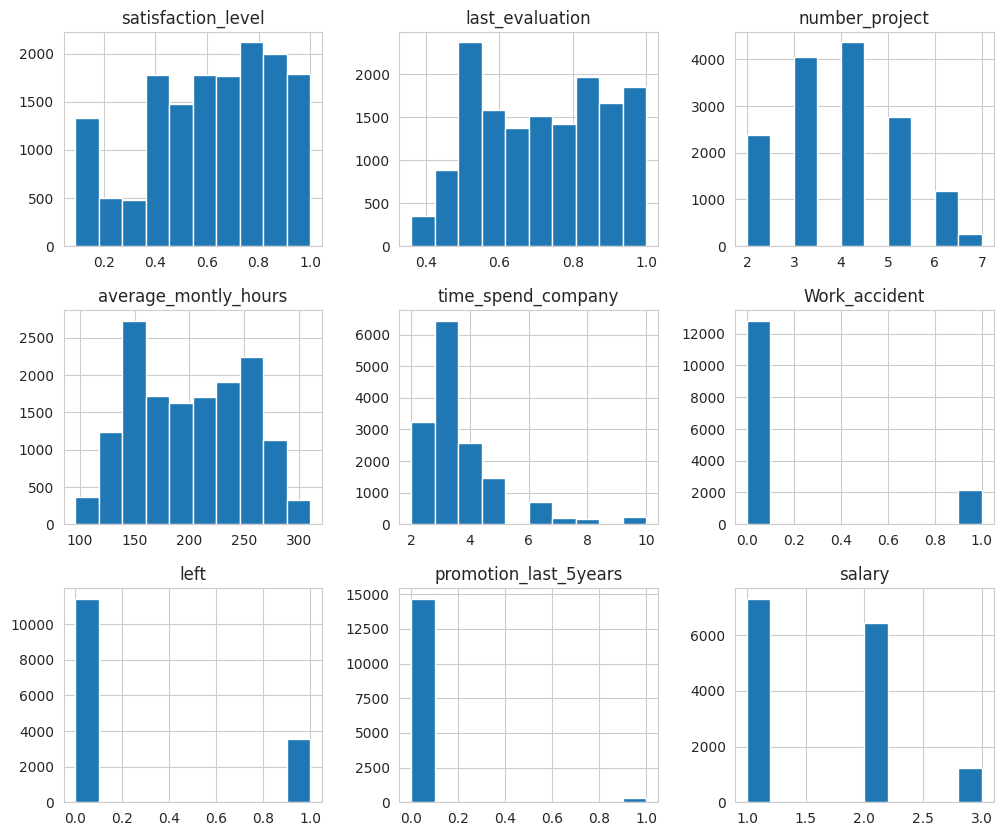

In [12]:
hr_data_clean.hist(figsize=(12, 10))
plt.show()

**Examining data intercorrelations**

<Axes: >

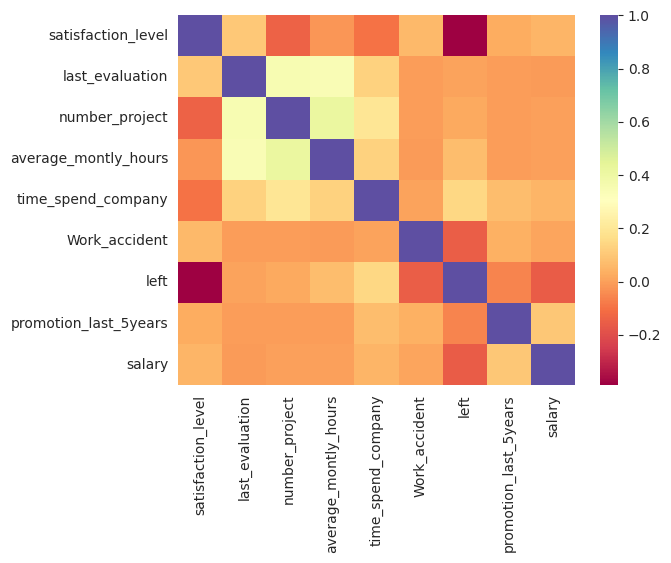

In [13]:
sns.heatmap(hr_data_clean.corr(), cmap="Spectral")

In [14]:
corr = hr_data_clean.corr()
corr

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605,0.050022
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684,-0.013002
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064,-0.001803
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544,-0.002242
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433,0.048715
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245,0.009247
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788,-0.157898
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000,0.098119
salary,0.050022,-0.013002,-0.001803,-0.002242,0.048715,0.009247,-0.157898,0.098119,1.000000


**Correlations  observed**

* Negative correlation of (-0.39) between satisfaction_level and the employees that left the company.
* The highest positive correlation is between number of projects and average monthly hours (0.42).
* Last_evaluation is high correlated to number_project(0.35)and average_monthly_hours(0.34). 
* Work_accident (-0.15)and salary (-0.16) have a low negative correlation with employees that left.

In [15]:
hr_data_clean.corr()['left'].sort_values(ascending=False)

left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
salary                  -0.157898
satisfaction_level      -0.388375
Name: left, dtype: float64

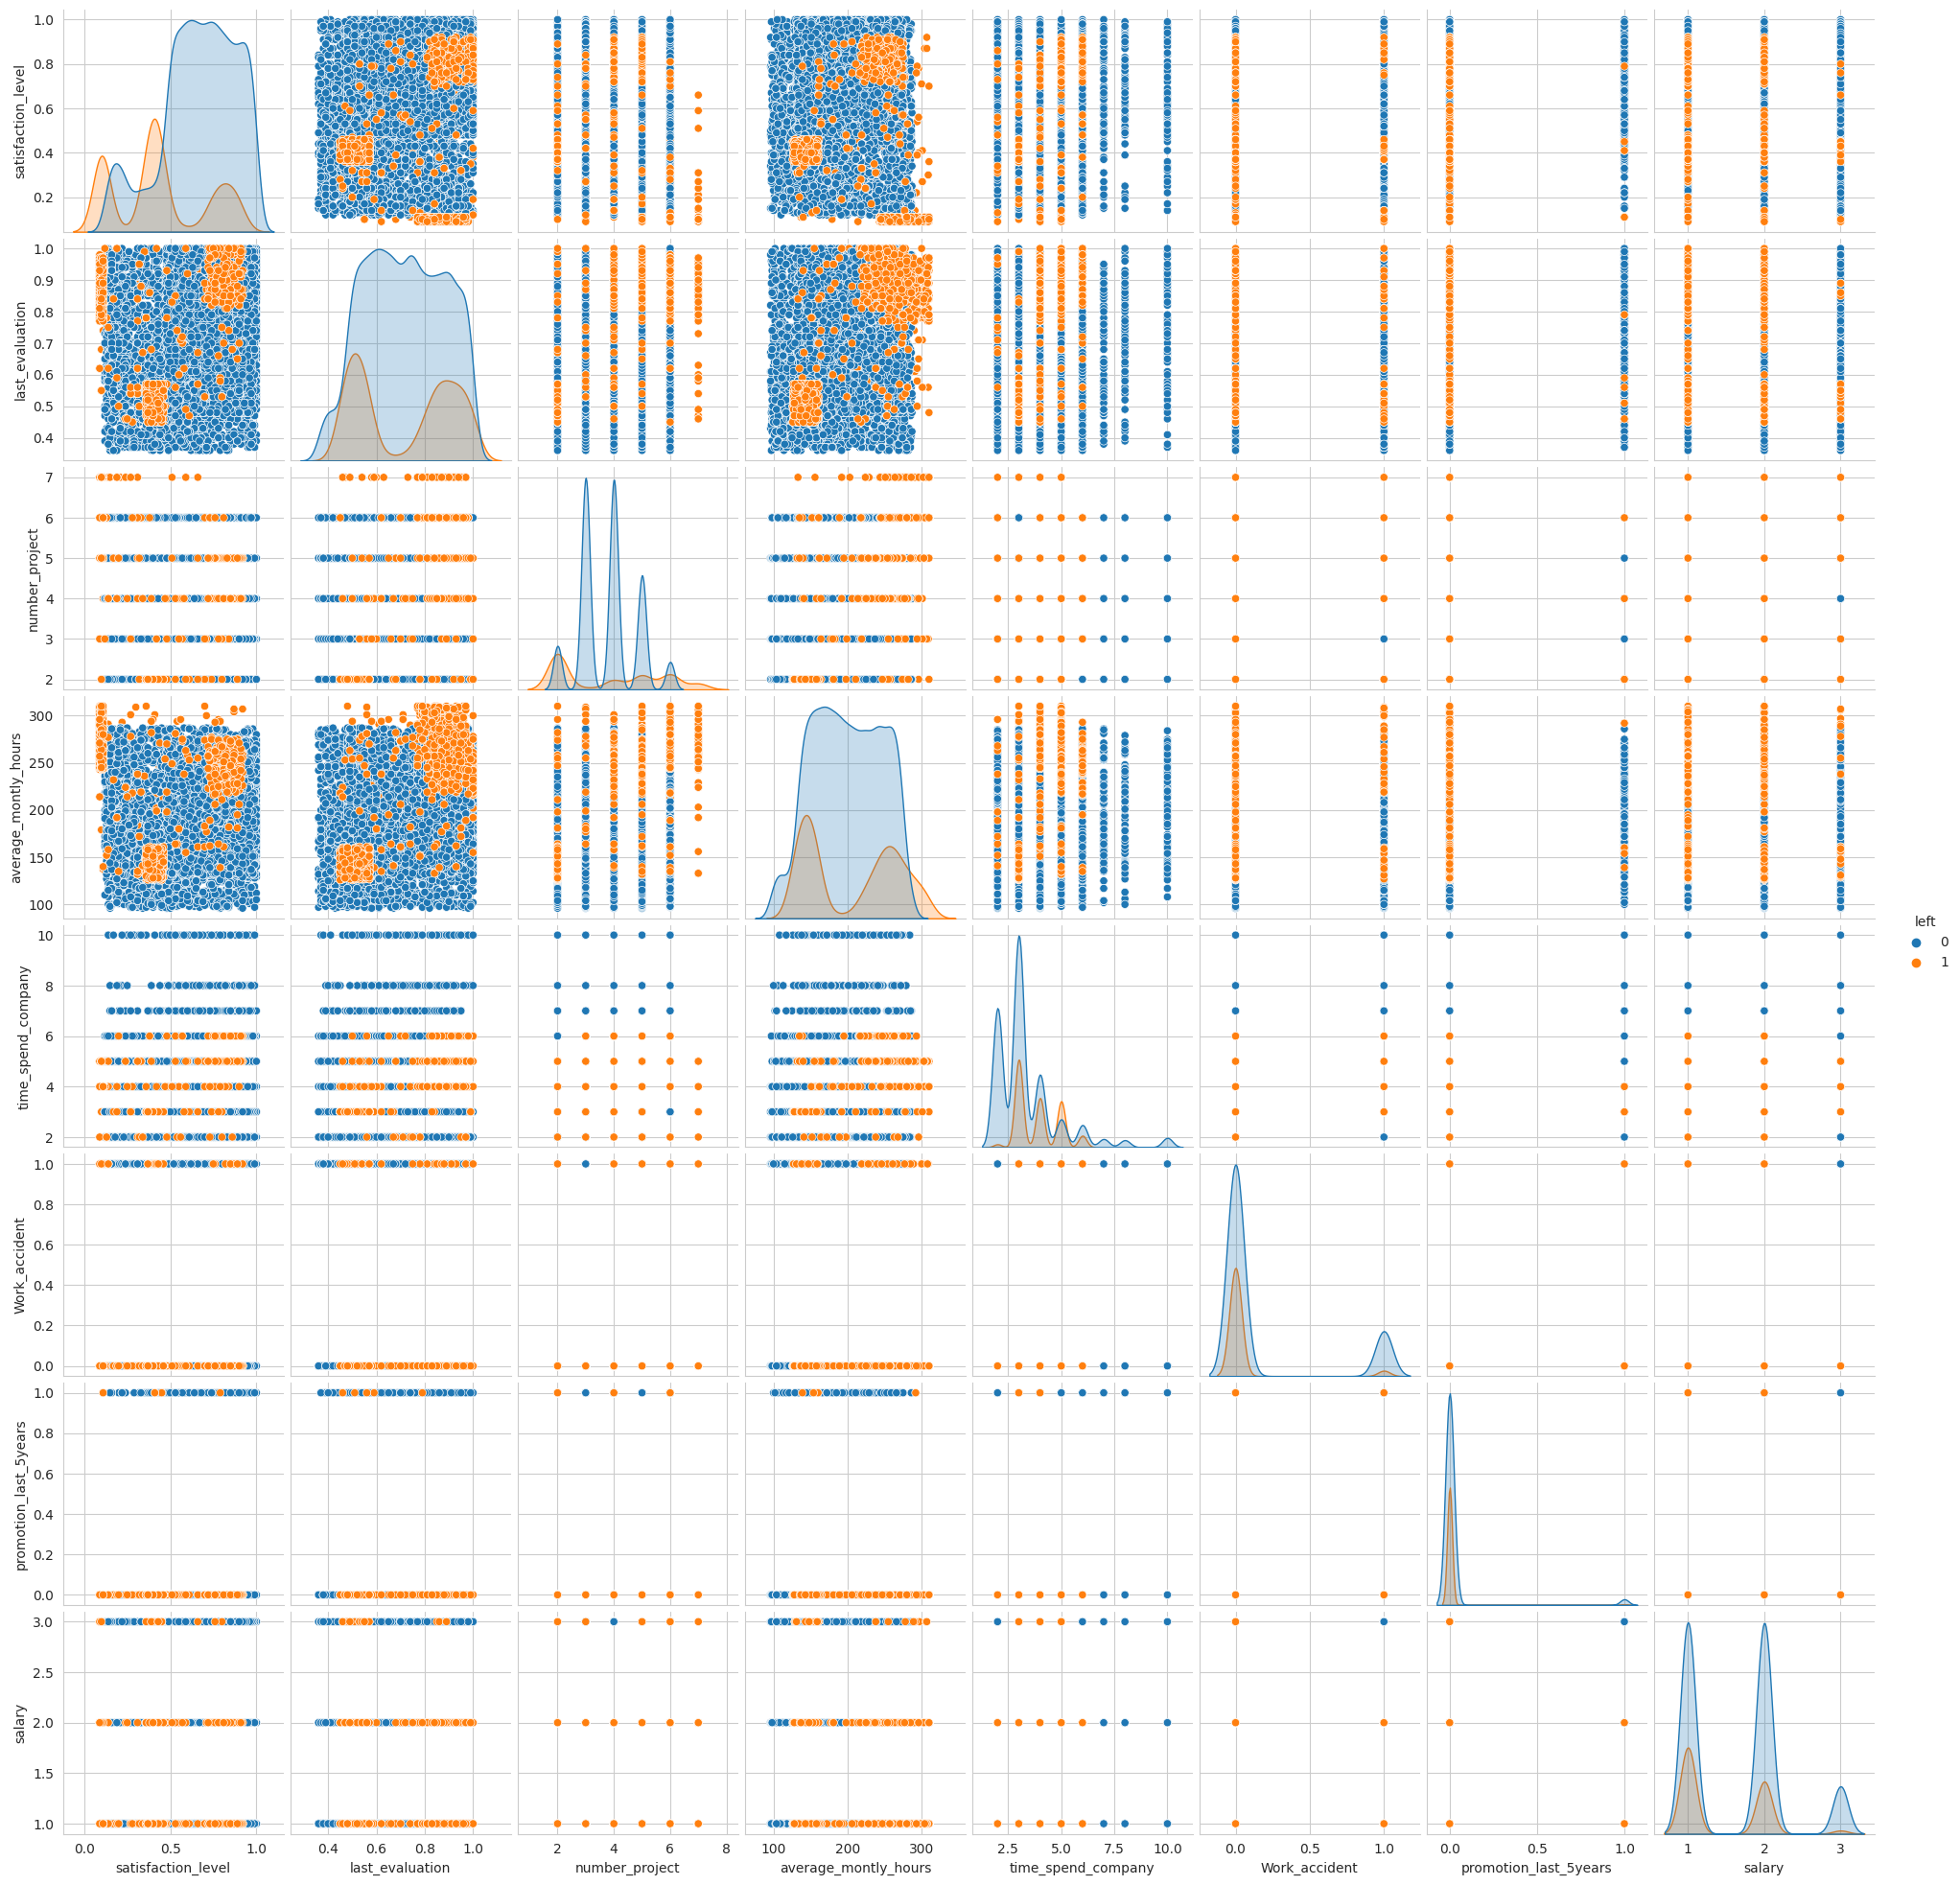

In [16]:
sns.pairplot(hr_data_clean, hue = 'left')

**Pair plot Observations**

* Too few or too high number of projects would decrease the satisfaction level and thus cause the employees to leave.
* When employees are overworked (more than an average of 200 hours/month), regarless of the satisfaction level, they decide to leave.
* Working over 300 hours/month the satisfaction levels drops significantly, causing them to leave.
* Employees ususally start leaving from the 3rd year; however, if their salaries are increased along with timely promotions by the 6th year, they tend to stay as long as 10 years.
* Employees who are promoted without a proper increase in their salary, tend to leave.

**Separating feature and target variables**

In [17]:
X = pd.get_dummies(hr_data_clean.drop('left', axis=1))
y = hr_data_clean['left'].astype('category')

**Rescaling the dataset**

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [19]:
X_train = scaler.fit_transform(X)
X_rescaled = pd.DataFrame(X_train, columns=X.columns)

In [20]:
X_rescaled.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.574542,0.556409,0.360611,0.490889,0.187279,0.144610,0.021268,0.297353
std,0.273220,0.267452,0.246518,0.233379,0.182517,0.351719,0.144281,0.318591
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.384615,0.312500,0.200000,0.280374,0.125000,0.000000,0.000000,0.000000
50%,0.604396,0.562500,0.400000,0.485981,0.125000,0.000000,0.000000,0.500000
75%,0.802198,0.796875,0.600000,0.696262,0.250000,0.000000,0.000000,0.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Train test split**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

#Building preliminary models

**Logistic Regression Model**

In [22]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(solver='liblinear')

In [23]:
logmodel.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [24]:
y_pred_LR = logmodel.predict(X_test)

In [25]:
confusion_matrix(y_test, y_pred_LR)

array([[3147,  269],
       [ 668,  416]])

In [26]:
report1 = classification_report(y_test, y_pred_LR)

In [27]:
print(report1)

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      3416
           1       0.61      0.38      0.47      1084

    accuracy                           0.79      4500
   macro avg       0.72      0.65      0.67      4500
weighted avg       0.77      0.79      0.77      4500



In [28]:
logmodel.coef_

array([[-4.12086799,  0.52575452, -0.30336444,  0.00420038,  0.26015986,
        -1.52386986, -1.49924905, -0.68390185]])

Checking for insignificant values

In [29]:
import statsmodels.api as sm
logit_model=sm.Logit(y_train, X_train)
logmodel_2=logit_model.fit()
print(logmodel_2.summary2())

Optimization terminated successfully.
         Current function value: 0.433564
         Iterations 7
                            Results: Logit
Model:                Logit              Pseudo R-squared:   0.208    
Dependent Variable:   left               AIC:                9119.9823
Date:                 2023-04-23 21:37   BIC:                9178.0546
No. Observations:     10499              Log-Likelihood:     -4552.0  
Df Model:             7                  LL-Null:            -5747.7  
Df Residuals:         10491              LLR p-value:        0.0000   
Converged:            1.0000             Scale:              1.0000   
No. Iterations:       7.0000                                          
----------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------
satisfaction_level    -3.8368   0.1093 -35.0888 0.0000 -4.0511 -3.6225
las

As we can see, there are no insignificant values.

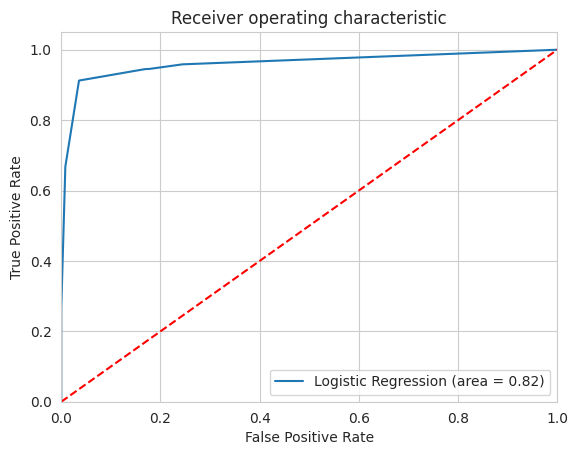

Roc Auc= 0.8150614754098362


In [116]:
logit_roc_auc = roc_auc_score(y_test, logmodel.predict_proba(X_test)[:,1])
logit_fpr, logit_tpr, logit_thresholds = roc_curve(y_test, logmodel.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()
print('Roc Auc=', logit_roc_auc)

In [31]:
logit_roc_auc

0.8150614754098362

**kNN Model**

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [33]:
y_pred = knn.predict(X_test)

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[3237  179]
 [  84 1000]]
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      3416
           1       0.85      0.92      0.88      1084

    accuracy                           0.94      4500
   macro avg       0.91      0.94      0.92      4500
weighted avg       0.94      0.94      0.94      4500



In [34]:
print('ROC AUC: ', roc_auc_score(y_test,y_pred))

ROC AUC:  0.935054378354088


In [35]:
from sklearn.model_selection import cross_val_score
max_K = 100
cv_scores = [ ]

for K in range(1,max_K):
    knn = KNeighborsClassifier(n_neighbors = K)
    scores = cross_val_score(knn,X_train,y_train.values.ravel(),cv = 5,scoring = "roc_auc")
    cv_scores.append(scores.mean())

In [36]:
selected_k=cv_scores.index(max(cv_scores))+1

print('Optimal k: ', cv_scores.index(max(cv_scores))+1)

Optimal k:  6


In [37]:
cv_scores[:4]

[0.9547573778521109,
 0.9674689355002417,
 0.9707323136981628,
 0.9724724959298865]

**Ploting k & roc_auc score**

Optimal number of neighbors: 6


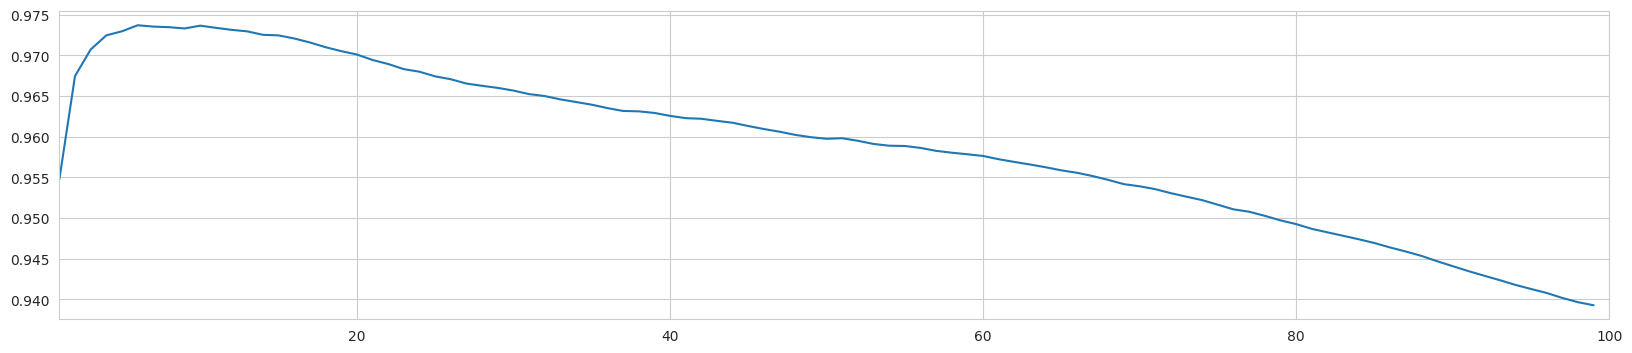

In [38]:
sns.set_style("whitegrid",{'axes.grid' : True})

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 4))  

ax = sns.lineplot(x=range(1,100), y=cv_scores)

ax.set(xlim=(1, 100))

print("Optimal number of neighbors:", 6)

**Rebuilding the model with optimal k**

In [39]:
knn = KNeighborsClassifier(n_neighbors=selected_k, metric='euclidean')

knn.fit(X_train, y_train)

y_pred_KNN = knn.predict(X_test)

In [40]:
print(confusion_matrix(y_test,y_pred_KNN))

[[3273  143]
 [  91  993]]


In [41]:
report2 = classification_report(y_test,y_pred_KNN)

In [42]:
print(report2)

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3416
           1       0.87      0.92      0.89      1084

    accuracy                           0.95      4500
   macro avg       0.92      0.94      0.93      4500
weighted avg       0.95      0.95      0.95      4500



In [43]:
knn_roc_auc = roc_auc_score(y_test,y_pred_KNN)

In [44]:
print('ROC AUC: ', knn_roc_auc)

ROC AUC:  0.9370949169093564


Decision Tree Model

In [45]:
from sklearn import tree

dt_model = tree.DecisionTreeClassifier(min_samples_leaf=5, max_depth=3)

dt_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=5)

In [46]:
y_pred_DT = dt_model.predict(X_test)

In [47]:
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix(y_test,y_pred_DT)

array([[3294,  122],
       [  95,  989]])

In [48]:
report3 = classification_report(y_test,y_pred_DT)

In [49]:
print(report3)

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3416
           1       0.89      0.91      0.90      1084

    accuracy                           0.95      4500
   macro avg       0.93      0.94      0.93      4500
weighted avg       0.95      0.95      0.95      4500



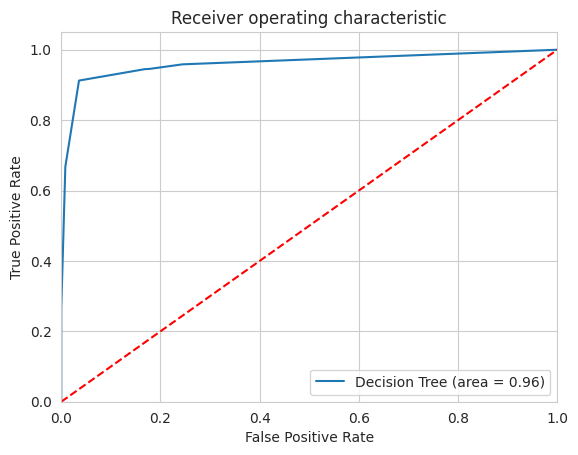

In [111]:
dt_roc_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])
dt_fpr, dt_tpr, dt_thresholds = roc_curve(y_test, dt_model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Decision Tree (area = %0.2f)' % dt_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

In [51]:
dt_roc_auc

0.9609802362660629

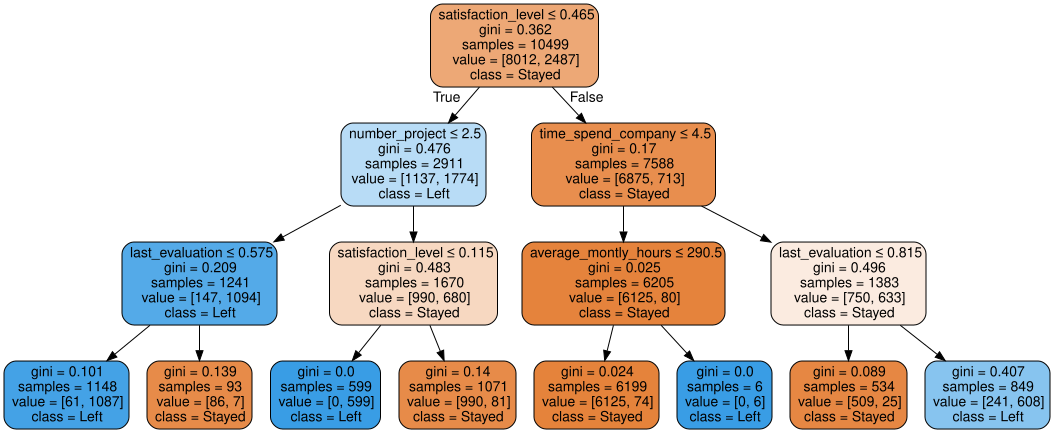

In [52]:
import graphviz 
dot_data = tree.export_graphviz(dt_model, out_file=None, 
                      feature_names=X.columns,  
                      class_names=['Stayed','Left'],
                      filled=True, rounded=True,  
                      special_characters=True)  
graph = graphviz.Source(dot_data)  
graph 

**Random Forest Model**

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model  = RandomForestClassifier(max_depth=5, random_state=0)
rf_model.fit(X_train,y_train)

y_pred_RF = rf_model.predict(X_test)

confusion_matrix(y_test,y_pred_RF)

array([[3400,   16],
       [ 141,  943]])

In [54]:
report4 = classification_report(y_test,y_pred_RF)

In [55]:
print(report4)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3416
           1       0.98      0.87      0.92      1084

    accuracy                           0.97      4500
   macro avg       0.97      0.93      0.95      4500
weighted avg       0.97      0.97      0.96      4500



**Boosted Tree Model**

In [56]:
from sklearn.ensemble import AdaBoostClassifier

bt_model = AdaBoostClassifier(n_estimators=100)

bt_model.fit(X_train,y_train)

y_pred_BT = bt_model.predict(X_test)

confusion_matrix(y_test,y_pred_BT)

array([[3329,   87],
       [  95,  989]])

In [57]:
report5 = classification_report(y_test,y_pred_BT)

In [58]:
print(report5)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3416
           1       0.92      0.91      0.92      1084

    accuracy                           0.96      4500
   macro avg       0.95      0.94      0.94      4500
weighted avg       0.96      0.96      0.96      4500



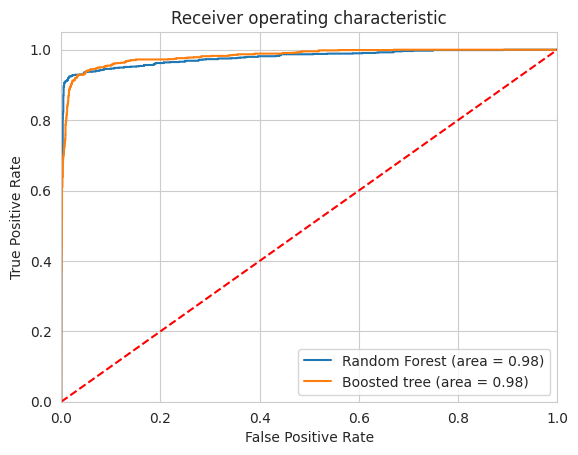

In [59]:
rf_roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

bt_roc_auc = roc_auc_score(y_test, bt_model.predict_proba(X_test)[:,1])
bt_fpr, bt_tpr, bt_thresholds = roc_curve(y_test, bt_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(rf_fpr, rf_tpr, label='Random Forest (area = %0.2f)' % rf_roc_auc)
plt.plot(bt_fpr, bt_tpr, label='Boosted tree (area = %0.2f)' % bt_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

In [60]:
rf_roc_auc

0.978321033210332

In [61]:
bt_roc_auc

0.9823098864038993

**Naive Bayes Model**

In [62]:
nb_model = MultinomialNB(alpha=0.01)
nb_model.fit(X_train, y_train) 

y_pred_NB = nb_model.predict(X_test)

print(confusion_matrix(y_test,y_pred_NB))

[[3416    0]
 [1084    0]]


In [63]:
report6 = classification_report(y_test,y_pred_NB)

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [64]:
print(report6)

              precision    recall  f1-score   support

           0       0.76      1.00      0.86      3416
           1       0.00      0.00      0.00      1084

    accuracy                           0.76      4500
   macro avg       0.38      0.50      0.43      4500
weighted avg       0.58      0.76      0.66      4500



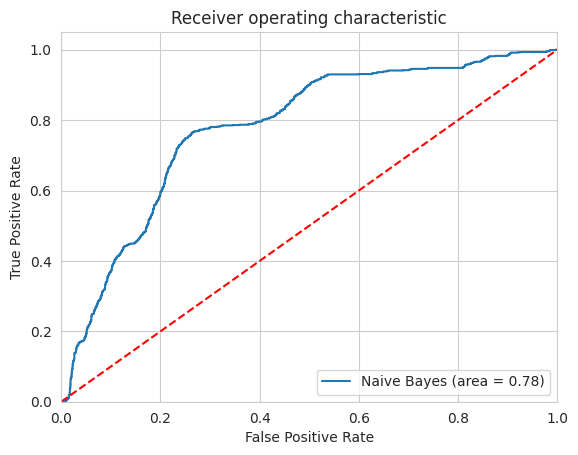

In [65]:
nb_roc_auc = roc_auc_score(y_test, nb_model.predict_proba(X_test)[:,1])
nb_fpr, nb_tpr, nb_thresholds = roc_curve(y_test, nb_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(nb_fpr, nb_tpr, label='Naive Bayes (area = %0.2f)' % nb_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [66]:
nb_roc_auc

0.778257786237113

**ANN Model**

In [67]:
from sklearn.neural_network import MLPClassifier

MLPC_model = MLPClassifier(hidden_layer_sizes=20, activation='logistic', solver='adam', random_state=1)

MLPC_model.fit(X_train, y_train)

y_pred_mlpc = MLPC_model.predict(X_test)

print(confusion_matrix(y_test,y_pred_mlpc))
print(classification_report(y_test,y_pred_mlpc))

[[3219  197]
 [ 192  892]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      3416
           1       0.82      0.82      0.82      1084

    accuracy                           0.91      4500
   macro avg       0.88      0.88      0.88      4500
weighted avg       0.91      0.91      0.91      4500



/usr/local/lib/python3.9/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [68]:
print('ROC AUC ANN: ', roc_auc_score(y_test,MLPC_model.predict_proba(X_test)[:,1]))

ROC AUC ANN:  0.9541770007864013


In [69]:
mlpc_roc_auc = roc_auc_score(y_test,MLPC_model.predict_proba(X_test)[:,1])

In [70]:
from sklearn.model_selection import cross_val_score
min_hidden_layer_size = 5
max_hidden_layer_size = 30
cv_scores = [ ]

for s in range(min_hidden_layer_size,max_hidden_layer_size,5):
    MLPC_model = MLPClassifier(hidden_layer_sizes=s, activation='logistic', solver='lbfgs', random_state=1)
    scores = cross_val_score(MLPC_model,X_train,y_train.values.ravel(),cv = 5,scoring = "accuracy")
    cv_scores.append(scores.mean())

/usr/local/lib/python3.9/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.9/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.9/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REAC

**Plotting**

<Axes: >

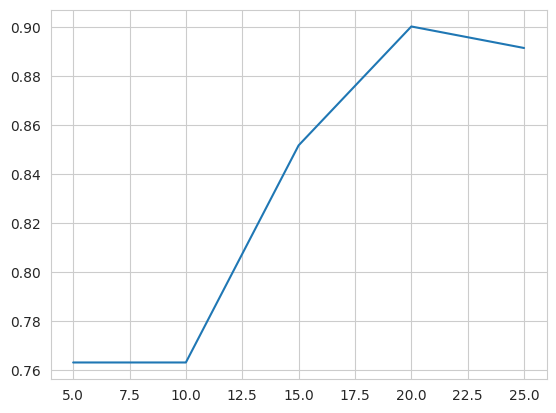

In [71]:
sns.set_style("whitegrid",{'axes.grid' : True})
sns.lineplot(x=range(min_hidden_layer_size,max_hidden_layer_size,5), y=cv_scores)

**Rebuilding the model with optimal no. of nodes**

In [72]:
MLPC_model2 = MLPClassifier(hidden_layer_sizes=10, activation='logistic', solver='adam', random_state=1)

MLPC_model2.fit(X_train, y_train)

y_pred_mlpc2 = MLPC_model2.predict(X_test)

print(confusion_matrix(y_test,y_pred_mlpc2))
print(classification_report(y_test,y_pred_mlpc2))

[[3197  219]
 [ 142  942]]
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3416
           1       0.81      0.87      0.84      1084

    accuracy                           0.92      4500
   macro avg       0.88      0.90      0.89      4500
weighted avg       0.92      0.92      0.92      4500



/usr/local/lib/python3.9/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [73]:
print('ROC AUC ANN2: ', roc_auc_score(y_test,MLPC_model2.predict_proba(X_test)[:,1]))

ROC AUC ANN2:  0.9608560107849323


In [74]:
mlpc_roc_auc2 = roc_auc_score(y_test,MLPC_model2.predict_proba(X_test)[:,1])

**Keras Model**

In [75]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense,Activation,Dropout
from tensorflow.keras.optimizers import Adam

In [76]:
model = Sequential()

model.add(Dense(units=100,activation='relu'))
model.add(Dense(units=50,activation='relu'))
model.add(Dense(units=25,activation='sigmoid'))
model.add(Dense(units=1,activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [77]:
model.fit(x=X_train, 
          y=y_train,
          batch_size=128, 
          epochs=100,
          validation_data=(X_test, y_test), verbose=1)

Epoch 1/100
83/83 [==============================] - 2s 6ms/step - loss: 0.5823 - val_loss: 0.5513
Epoch 2/100
83/83 [==============================] - 0s 4ms/step - loss: 0.5471 - val_loss: 0.5516
Epoch 3/100
83/83 [==============================] - 0s 4ms/step - loss: 0.5497 - val_loss: 0.5540
Epoch 4/100
83/83 [==============================] - 0s 4ms/step - loss: 0.5479 - val_loss: 0.5522
Epoch 5/100
83/83 [==============================] - 1s 6ms/step - loss: 0.5477 - val_loss: 0.5522
Epoch 6/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5475 - val_loss: 0.5521
Epoch 7/100
83/83 [==============================] - 0s 6ms/step - loss: 0.5475 - val_loss: 0.5521
Epoch 8/100
83/83 [==============================] - 0s 6ms/step - loss: 0.5489 - val_loss: 0.5521
Epoch 9/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5480 - val_loss: 0.5521
Epoch 10/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5476 - val_loss: 0.5522
Epoch 11/

**Model History History**

<Axes: >

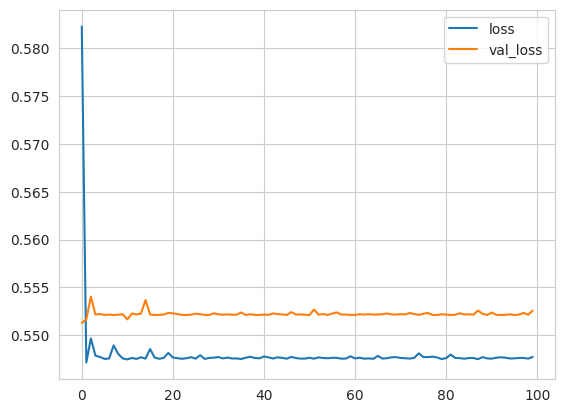

In [78]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

**Early Stopping**

In [79]:
model = Sequential()
model.add(Dense(units=100,activation='relu'))
model.add(Dense(units=50,activation='relu'))
model.add(Dense(units=25,activation='sigmoid'))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [80]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

In [81]:
model.fit(x=X_train, 
          y=y_train, 
          batch_size=128,
          epochs=100,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/100
83/83 [==============================] - 1s 5ms/step - loss: 0.5483 - val_loss: 0.5519
Epoch 2/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5478 - val_loss: 0.5614
Epoch 3/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5498 - val_loss: 0.5601
Epoch 4/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5492 - val_loss: 0.5520
Epoch 5/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5475 - val_loss: 0.5522
Epoch 6/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5472 - val_loss: 0.5514
Epoch 7/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5474 - val_loss: 0.5526
Epoch 8/100
83/83 [==============================] - 0s 5ms/step - loss: 0.5475 - val_loss: 0.5521
Epoch 9/100
83/83 [==============================] - 0s 3ms/step - loss: 0.5468 - val_loss: 0.5529
Epoch 10/100
83/83 [==============================] - 0s 3ms/step - loss: 0.5455 - val_loss: 0.5441
Epoch 11/

<Axes: >

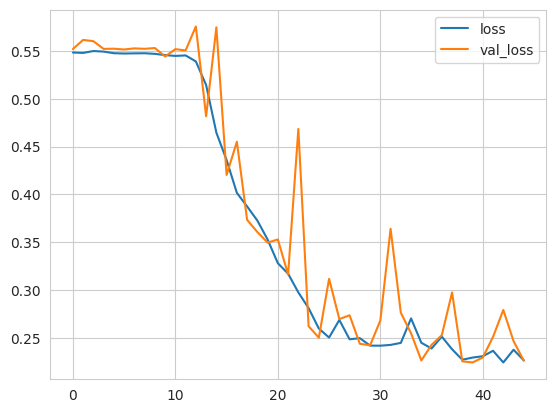

In [82]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

**Dropout**

In [83]:
model = Sequential()

model.add(Dense(units=100,activation='relu'))
model.add(Dropout(0.5)) 

model.add(Dense(units=50,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=25,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(units=1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam')

In [84]:
model.fit(x=X_train, 
          y=y_train, 
          batch_size=128,
          epochs=200,
          validation_data=(X_test, y_test), verbose=1,
          callbacks=[early_stop]
          )

Epoch 1/200
83/83 [==============================] - 2s 6ms/step - loss: 6.7787 - val_loss: 0.6670
Epoch 2/200
83/83 [==============================] - 0s 4ms/step - loss: 1.4248 - val_loss: 0.5881
Epoch 3/200
83/83 [==============================] - 0s 4ms/step - loss: 0.8461 - val_loss: 0.6059
Epoch 4/200
83/83 [==============================] - 0s 4ms/step - loss: 0.6956 - val_loss: 0.5901
Epoch 5/200
83/83 [==============================] - 0s 4ms/step - loss: 0.6551 - val_loss: 0.5816
Epoch 6/200
83/83 [==============================] - 0s 4ms/step - loss: 0.6152 - val_loss: 0.5824
Epoch 7/200
83/83 [==============================] - 0s 4ms/step - loss: 0.6078 - val_loss: 0.5697
Epoch 8/200
83/83 [==============================] - 0s 4ms/step - loss: 0.5864 - val_loss: 0.5661
Epoch 9/200
83/83 [==============================] - 0s 4ms/step - loss: 0.5763 - val_loss: 0.5674
Epoch 10/200
83/83 [==============================] - 0s 4ms/step - loss: 0.5795 - val_loss: 0.5657
Epoch 11/

<Axes: >

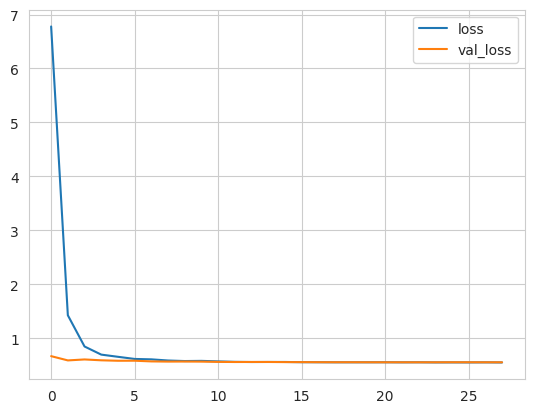

In [85]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [86]:
y_pred_keras =(model.predict(X_test) > 0.5).astype("int32")

141/141 [==============================] - 0s 2ms/step


In [87]:
print(confusion_matrix(y_test,y_pred_keras))

[[3416    0]
 [1084    0]]


In [88]:
print(classification_report(y_test,y_pred_keras))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86      3416
           1       0.00      0.00      0.00      1084

    accuracy                           0.76      4500
   macro avg       0.38      0.50      0.43      4500
weighted avg       0.58      0.76      0.66      4500



/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [89]:
keras_roc_auc = roc_auc_score(y_test,model.predict(X_test))

141/141 [==============================] - 0s 1ms/step


In [90]:
print('ROC AUC Keras: ', roc_auc_score(y_test,model.predict(X_test)))

141/141 [==============================] - 0s 2ms/step
ROC AUC Keras:  0.5513359100218637


#Choosing the Best Model

In [91]:
report1 = classification_report(y_test,y_pred_LR, output_dict=True)
report2 = classification_report(y_test,y_pred_KNN, output_dict=True)
report3 = classification_report(y_test,y_pred_RF, output_dict=True)
report4 = classification_report(y_test,y_pred_BT, output_dict=True)
report5 = classification_report(y_test,y_pred_NB, output_dict=True)
report6 = classification_report(y_test,y_pred_mlpc2, output_dict=True)
report7 = classification_report(y_test,y_pred_keras, output_dict=True)

/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.9/dist-packages/sklearn/metrics/_classificat

In [106]:
roc_auc1 = logit_roc_auc
roc_auc2 = knn_roc_auc
roc_auc3 = rf_roc_auc
roc_auc4 = bt_roc_auc
roc_auc5 = nb_roc_auc
roc_auc6 = mlpc_roc_auc2
roc_auc7 = keras_roc_auc

In [107]:
performance = {
    'precision': [report1['weighted avg']['precision'], report2['weighted avg']['precision'], report3['weighted avg']['precision'], report4['weighted avg']['precision'], report5['weighted avg']['precision'], report6['weighted avg']['precision'], report7['weighted avg']['precision']],
    'recall': [report1['weighted avg']['recall'], report2['weighted avg']['recall'], report3['weighted avg']['recall'], report4['weighted avg']['recall'], report5['weighted avg']['recall'], report6['weighted avg']['recall'], report7['weighted avg']['recall']],
    'f1-score': [report1['weighted avg']['f1-score'], report2['weighted avg']['f1-score'], report3['weighted avg']['f1-score'], report4['weighted avg']['f1-score'], report5['weighted avg']['f1-score'], report6['weighted avg']['f1-score'], report7['weighted avg']['f1-score']],
    'ROC AUC': [roc_auc1, roc_auc2, roc_auc3, roc_auc4, roc_auc5, roc_auc6, roc_auc7]
}
df = pd.DataFrame(performance, index=['Logistic Regression', 'kNN', 'Random Forest', 'Boosted Tree', 'Naive Bayes', 'ANN', 'Keras'])
display(df)

,precision,recall,f1-score,ROC AUC
Logistic Regression,0.772484,0.791778,0.774040,0.815061
kNN,0.949142,0.948000,0.948410,0.937095
Random Forest,0.965754,0.965111,0.964357,0.978321
Boosted Tree,0.959461,0.959556,0.959504,0.982310
Naive Bayes,0.576250,0.759111,0.655160,0.778258
ANN,0.922278,0.919778,0.920696,0.960856
Keras,0.576250,0.759111,0.655160,0.551336


When all the models are compared, the Naive Bayes and Keras models have lower Precision, Recall, F1-score and ROC AUC. The models with the highest ROC AUC are the Boosted Tree model, Random Forest model and ANN model. The Random Forest model is, therefore, the best model with the highest Precision, Recall, F1 as well as ROC AUC score of 0.98.


141/141 [==============================] - 0s 1ms/step


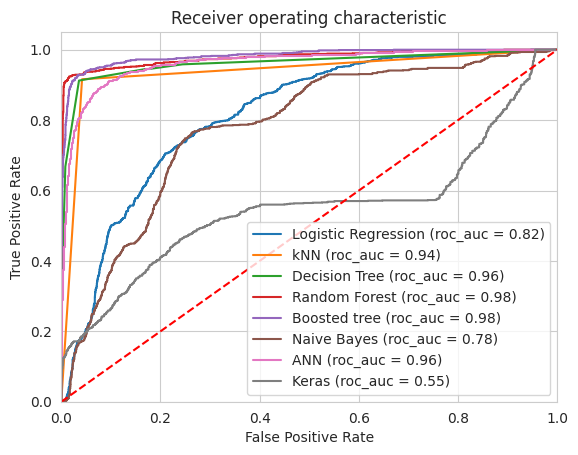

In [118]:
logit_roc_auc = roc_auc_score(y_test, logmodel.predict_proba(X_test)[:,1])
logit_fpr, logit_tpr, logit_thresholds = roc_curve(y_test, logmodel.predict_proba(X_test)[:,1])

knn_roc_auc = roc_auc_score(y_test,y_pred_KNN)
knn_fpr, knn_tpr, knn_thresholds = roc_curve(y_test,y_pred_KNN)

dt_roc_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])
dt_fpr, dt_tpr, thresholds = roc_curve(y_test, dt_model.predict_proba(X_test)[:,1])

rf_roc_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

bt_roc_auc = roc_auc_score(y_test, bt_model.predict_proba(X_test)[:,1])
bt_fpr, bt_tpr, bt_thresholds = roc_curve(y_test, bt_model.predict_proba(X_test)[:,1])

nb_roc_auc = roc_auc_score(y_test, nb_model.predict_proba(X_test)[:,1])
nb_fpr, nb_tpr, nb_thresholds = roc_curve(y_test, nb_model.predict_proba(X_test)[:,1])

mlpc_roc_auc2 = roc_auc_score(y_test,MLPC_model2.predict_proba(X_test)[:,1])
mlpc_fpr, mlpc_tpr, mlpc_thresholds = roc_curve(y_test,MLPC_model2.predict_proba(X_test)[:,1])

keras_roc_auc = roc_auc_score(y_test,model.predict(X_test))
keras_fpr, keras_tpr, keras_thresholds = roc_curve(y_test,model.predict(X_test))

plt.figure()
plt.plot(logit_fpr, logit_tpr, label='Logistic Regression (roc_auc = %0.2f)' % logit_roc_auc)
plt.plot(knn_fpr, knn_tpr, label='kNN (roc_auc = %0.2f)' % knn_roc_auc)
plt.plot(dt_fpr, dt_tpr, label='Decision Tree (roc_auc = %0.2f)' % dt_roc_auc)
plt.plot(rf_fpr, rf_tpr, label='Random Forest (roc_auc = %0.2f)' % rf_roc_auc)
plt.plot(bt_fpr, bt_tpr, label='Boosted tree (roc_auc = %0.2f)' % bt_roc_auc)
plt.plot(nb_fpr, nb_tpr, label='Naive Bayes (roc_auc = %0.2f)' % nb_roc_auc)
plt.plot(mlpc_fpr, mlpc_tpr, label='ANN (roc_auc = %0.2f)' % mlpc_roc_auc2)
plt.plot(keras_fpr, keras_tpr, label='Keras (roc_auc = %0.2f)' % keras_roc_auc)

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

#Debugging the models

In [96]:
!pip install eli5

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107747 sha256=e37a48e6677df6cb66921aecb69e0246a62051636f962c8aae24e314187331f9
  Stored in directory: /root/.cache/pip/wheels/7b/26/a5/8460416695a992a2966b41caa5338e5e7fcea98c9d032d055c
Successfully built eli5


**Calculating the importance of each feature in model performance**

In [97]:
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(nb_model, random_state=1).fit(X_test, y_test)
eli5.show_weights(perm, feature_names = X_test.columns.tolist())

Weight,Feature
0.0002 ± 0.0003,salary
0 ± 0.0000,promotion_last_5years
0 ± 0.0000,Work_accident
0 ± 0.0000,average_montly_hours
0 ± 0.0000,number_project
0 ± 0.0000,last_evaluation
0 ± 0.0000,satisfaction_level
-0.0002 ± 0.0003,time_spend_company


We can see that, 'salary' has a strong positive impact on our ability to predict why employees tend to leave.
On the other hand, 'time_spend_company' has a strong negative impact on our ability to predict why employees tend to leave.

The other features do not have much impact on the prediction ability and therefore, should be removed to build a better model.